# Notebook 04.1 — Geração de Isócronas (Áreas de Abrangência)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — Pipeline AE2SFCA  
**Autor:** Felipe Ramos Dantas  
**Programa:** MAPEPROF / IFPI  

---
## Objetivo
Esta etapa representa a espacialização da acessibilidade. Utilizando a malha viária com as impedâncias calculadas (minutos de viagem), geramos polígonos de alcance máximo (isócronas) ao redor de cada Unidade Básica de Saúde (UBS).

Para garantir a precisão urbana, utilizamos o método **Concave Hull KNN** da biblioteca `city2graph`. Diferente do polígono convexo (*Convex Hull*) que cria um "lençol" cobrindo áreas inalcançáveis (como rios ou quadras sem ruas), o envoltório côncavo "abraça" estritamente a topologia da rede viária por onde o paciente realmente consegue transitar.

In [1]:
# ── Bibliotecas Essenciais ──────────────────────────────────────────────────
import warnings
import pandas as pd
import geopandas as gpd
from pathlib import Path
from tqdm.auto import tqdm

# ── API Oficial City2Graph ──────────────────────────────────────────────────
import city2graph as c2g
import city2graph.morphology as c2g_morpho
import city2graph.utils as c2g_utils

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# 1. Definição de caminhos e carregamento dos dados
PROCESSED_PATH = Path('../dados/processados')
VECTORS_PATH = Path('../outputs/vectors')
VECTORS_PATH.mkdir(parents=True, exist_ok=True)



In [2]:
# 1. Carregando os limites da Fase 1 (se certifique que o caminho está correto)
RAW_IBGE_PATH = Path('../dados/brutos/ibge')
zu_normal = gpd.read_parquet(RAW_IBGE_PATH / "teresina_zonaUrbana_utm.parquet")
zu_5km = gpd.read_parquet(RAW_IBGE_PATH / "teresina_zonaUrbanaClip_utm.parquet")

print("🔄 Carregando dados da Fase 3...")
# Carregamos a malha já com os tempos calculados no NB 03
roads_gdf = gpd.read_parquet(PROCESSED_PATH / "zonaUrbanaReal_5km_road_routed.parquet")

# Carregamos as UBS (Oferta de Saúde)
ubs_gdf = gpd.read_file(Path('../dados/terceiros/semplam/ubs_zonaUrbana.geojson')).to_crs(31983)

🔄 Carregando dados da Fase 3...


In [ ]:
# # 2. Construção do Grafo Primal com pesos
# G = c2g_morpho.segments_to_graph(
#     roads_gdf, 
#     multigraph=True, 
#     as_nx=True
# )

# print(f"✅ Grafo pronto: {G.number_of_nodes():,} nós. Pronto para roteamento multimodal.")

# # 2. Construção do Grafo Primal com pesos
# Representação do grafo gerada uma vez só
nodes, edges = c2g.morphology.segments_to_graph(roads_gdf, multigraph=True, as_nx=False)
print(f"✅ Grafo pronto: {len(nodes):,} nós. Pronto para roteamento multimodal.")

Removed 29 invalid geometries


✅ Grafo pronto: 30,886 nós. Pronto para roteamento multimodal.


## Parâmetros do Algoritmo de Roteamento

A geração das isócronas utiliza a função `create_isochrone` iterativamente. A escolha metodológica dos parâmetros baseia-se em:
* **`threshold`**: Vetor de limiares `[10, 20, 30]`. Representa os tempos máximos aceitáveis de deslocamento no modelo de decaimento do AE2SFCA.
* **`edge_attr`**: Definido como `tempo_carro_min`. A métrica de distância euclidiana é substituída pelo custo real de tempo, considerando a hierarquia da via.
* **`method = 'concave_hull_knn'`**: Método que conecta as pontas das ruas alcançáveis gerando uma fronteira realista da área de serviço, mitigando a superestimação de alcance.

In [4]:
# ── 3. Cálculo das Isócronas por UBS (Em Formato de Anéis) ──────────────────

limiares_teoricos = [10, 20, 30]

# CUSTO DE TERMINAL (Adaptação Campanelli et al., 2026)
# Estimamos 4 minutos perdidos (ex: manobrar, estacionar e caminhar até a UBS)
TEMPO_ESTACIONAMENTO = 4

# Ajustamos o "orçamento" de tempo do algoritmo descontando a penalidade.
# Assim, uma isócrona nominal de 30 min rodará na rede apenas por 26 min.
limiares_efetivos = [t - TEMPO_ESTACIONAMENTO for t in limiares_teoricos]

print(f"🗺️ Tempos originais: {limiares_teoricos} min")
print(f"🗺️ Tempos efetivos na malha viária: {limiares_efetivos} min")

saidas = []
print("🗺️ Processando isócronas e gerando anéis de decaimento (donuts)...")

# .head(1) seleciona apenas a primeira UBS da tabela
ubs_teste_unica = ubs_gdf.head(5)

print("🧪 Iniciando teste para 1 UBS...")

for _, ubs in tqdm(ubs_teste_unica.iterrows(), total=len(ubs_teste_unica), desc="Analisando UBS"):
    ubs_id = ubs.get('cnes', ubs.name)

    try:
        iso = c2g_utils.create_isochrone(
            # graph=G,
            nodes=nodes,
            edges=edges,
            center_point=ubs.geometry,
            threshold=limiares_efetivos,
            edge_attr='tempo_carro_min',
            # 💡 DICA: Altere o método aqui para testar (ex: "concave_hull_knn", "convex_hull", "concave_hull_alpha")
            method="concave_hull_alpha", 
            # k = 10, # use apenas para 'concave_hull_knn'
            hull_ratio=0.15, # use apenas para 'concave_hull_alpha'
            allow_holes=False # use apenas para 'concave_hull_alpha'
        )

        # Garante que os limites estejam em ordem crescente (ex: 6, 16, 26)
        iso = iso.sort_values('threshold').reset_index(drop=True)

        # ── LÓGICA DE ANÉIS GEOMÉTRICOS (DONUTS) ──
        # O polígono atual passa a ser ele mesmo MENOS o polígono imediatamente anterior
        geometrias_aneis = []
        poligono_anterior = None
        
        for idx, row in iso.iterrows():
            geometria_atual = row.geometry
            if poligono_anterior is not None:
                # Subtrai a área interna para criar o anel
                anel = geometria_atual.difference(poligono_anterior)
            else:
                # O primeiro limiar (0 a 10 min) é a zona núcleo (já é o próprio polígono)
                anel = geometria_atual
            
            geometrias_aneis.append(anel)
            poligono_anterior = geometria_atual # Atualiza para o próximo passo
            
        # Substitui os polígonos cheios pelos anéis calculados
        iso['geometry'] = geometrias_aneis

        # Atribui metadados
        # Recuperamos o rótulo original (10, 20, 30) para manter o padrão na legenda do mapa
        iso['threshold_nominal'] = iso['threshold'] + TEMPO_ESTACIONAMENTO
        iso['ubs_id'] = ubs_id
        saidas.append(iso)

    except Exception as e:
        print(f"⚠️ Aviso: Falha ao gerar isócrona para UBS {ubs_id}. Detalhe: {e}")

isocronas = gpd.GeoDataFrame(pd.concat(saidas, ignore_index=True), geometry='geometry', crs=31983)
print(f"✅ Isocrona concluído! {len(isocronas)} polígonos gerados.")

🗺️ Tempos originais: [10, 20, 30] min
🗺️ Tempos efetivos na malha viária: [6, 16, 26] min
🗺️ Processando isócronas e gerando anéis de decaimento (donuts)...
🧪 Iniciando teste para 1 UBS...


Analisando UBS: 100%|██████████| 5/5 [01:19<00:00, 15.93s/it]


✅ Isocrona concluído! 15 polígonos gerados.


🗺️ Gerando visualização cartográfica rápida...


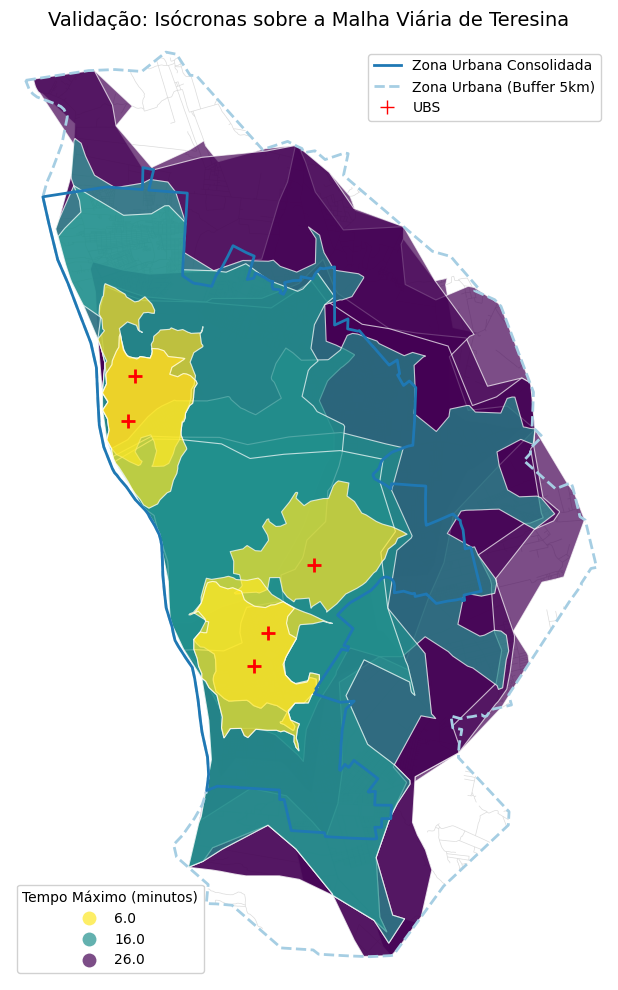

In [5]:
print("🗺️ Gerando visualização cartográfica rápida...")

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#f8f9fa')

# Plot dos Limites Territoriais (Pano de fundo absoluto)
# O zorder=0 garante que fiquem atrás do asfalto
zu_5km.plot(ax=ax, color='none', edgecolor='#a6cee3', linewidth=2, linestyle='--', zorder=3)
zu_normal.plot(ax=ax, color='none', edgecolor='#1f78b4', linewidth=2, zorder=4)

# 1. Plot da Malha Viária (Pano de Fundo)
# Usamos zorder=1 para ficar por baixo de tudo e cores claras para não poluir
roads_gdf.plot(ax=ax, color='#cccccc', linewidth=0.5, alpha=0.7, zorder=1)

# 2. Plot das Isócronas
# Ordenamos do maior para o menor tempo para que o polígono de 10 min não seja escondido pelo de 30 min
isocronas.sort_values('threshold', ascending=False).plot(
    column='threshold',
    ax=ax,
    cmap='viridis_r', # Paleta de cores invertida (cores mais "quentes/escuras" no centro)
    alpha=0.7,
    edgecolor='white',
    linewidth=0.8,
    categorical=True,
    legend=True,
    legend_kwds={
        'title': "Tempo Máximo (minutos)", 
        'loc': 'lower left', # Movido para a esquerda para não colidir com a outra legenda
        'framealpha': 0.9
    },
    zorder=2
)

# 3. Plot das UBS (Origens)
# Pegamos apenas as UBS que foram processadas nesta rodada (útil se você rodou o teste de 1 ou 5 UBS)
ubs_processadas = ubs_gdf[ubs_gdf.index.isin(isocronas['ubs_id']) | ubs_gdf['cnes'].isin(isocronas['ubs_id'])]
ubs_processadas.plot(ax=ax, color='red', marker='+', markersize=100, linewidth=2, zorder=3, label='UBS')

# 4. Zoom Automático para a Extensão das Isócronas
# Pega os limites (caixa delimitadora) apenas das áreas geradas
minx, miny, maxx, maxy = isocronas.total_bounds
buffer = 1000 # Folga de 500 metros nas bordas para o mapa "respirar"

ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

# 7. Adicionando as fronteiras à legenda
legenda_zu_5km = Line2D([0], [0], color='#a6cee3', lw=2, linestyle='--', label='Zona Urbana (Buffer 5km)')
legenda_zu_normal = Line2D([0], [0], color='#1f78b4', lw=2, label='Zona Urbana Consolidada')
legenda_ubs = Line2D([0], [0], marker='+', color='red', linestyle='None', markersize=10, label='UBS')

# Captura a legenda existente (dos tempos de viagem) e adiciona a nova
legenda_atual = ax.get_legend()
ax.legend(handles=[legenda_zu_normal, legenda_zu_5km, legenda_ubs], loc='upper right', framealpha=0.9)
if legenda_atual:
    ax.add_artist(legenda_atual) # Mantém as duas legendas no mapa

# 5. Acabamento
ax.set_title("Validação: Isócronas sobre a Malha Viária de Teresina", fontsize=14, pad=15)
ax.axis('off') # Remove os eixos de coordenadas para focar na geometria

plt.tight_layout()
plt.show()

In [6]:
isocronas.to_parquet(PROCESSED_PATH / "isocronas_carro_t5.parquet", index=False)
print(f"Isócronas: {len(isocronas)} ({len(ubs_gdf)} UBS × {len(limiares_teoricos)} limiares)")

Isócronas: 15 (75 UBS × 3 limiares)


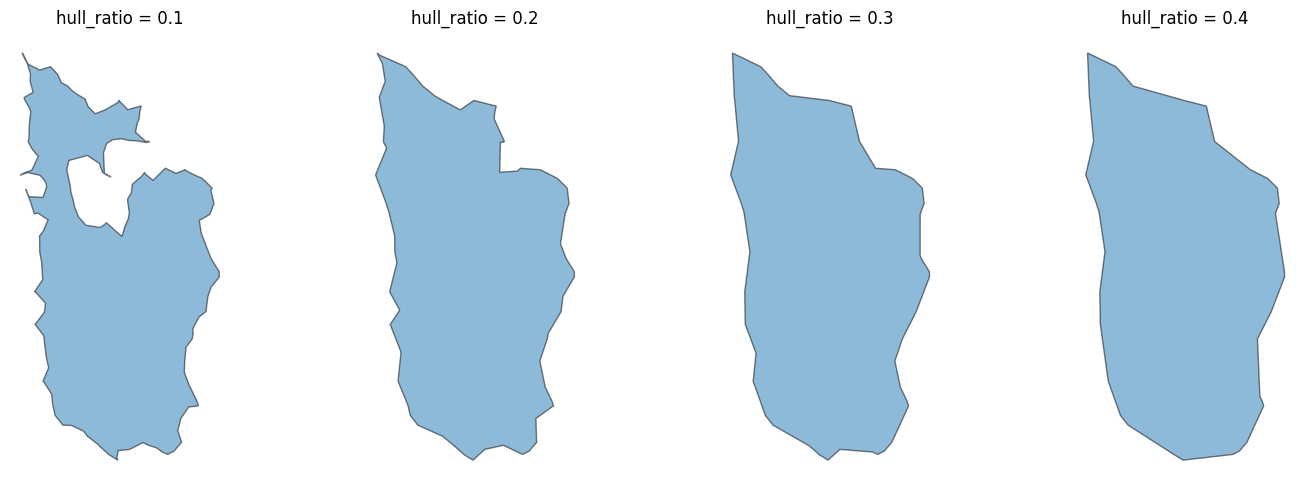

In [40]:
import matplotlib.pyplot as plt

ubs0 = ubs_gdf.iloc[0]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, hr in zip(axes, [0.1, 0.2, 0.3, 0.4]):
    iso = c2g.utils.create_isochrone(
        nodes=nodes, edges=edges,
        center_point=ubs0.geometry,
        threshold=[5],
        edge_attr='tempo_carro_min',
        method="concave_hull_alpha",
        hull_ratio=hr,
    )
    iso.plot(ax=ax, alpha=0.5, edgecolor='black')
    ax.set_title(f"hull_ratio = {hr}")
    ax.set_axis_off()
plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plotagem rápida para validação
fig, ax = plt.subplots(figsize=(10, 10))
isocronas.plot(column='threshold', ax=ax, cmap='viridis_r', alpha=0.6, legend=True)
ubs_gdf.plot(ax=ax, color='red', markersize=5)
ax.set_title("Isócronas de Acessibilidade às UBS (Carro)")
plt.show()

# Exportar para inspeção no QGIS
isocronas.to_file(Path('../outputs/vectors/isocronas_ubs.gpkg'), driver='GPKG')
print("💾 Isócronas salvas para análise final no QGIS.")